In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

In [6]:
import numpy as np

In [7]:
#loading data

races = pd.read_csv('dataset/races.csv')
results = pd.read_csv('dataset/results.csv')
drivers = pd.read_csv('dataset/drivers.csv')
constructors = pd.read_csv('dataset/constructors.csv')
circuits = pd.read_csv('dataset/circuits.csv')
lap = pd.read_csv('dataset/lap_times.csv')
seasons = pd.read_csv('dataset/seasons.csv')
sprint_results = pd.read_csv('dataset/sprint_results.csv')
status = pd.read_csv('dataset/status.csv')
pit_stops = pd.read_csv('dataset/pit_stops.csv')

Research Objective:
    
To examine how pit frequency and timing impacts race performance and to identify common strategy patterns using statistical and machine learning approaches.

Research Problem:

Pit Stop Strategy is a key determinant in Formula 1 race outcomes, yet its quantifable relationship to finishing position remains underexplored in public datasets

In [8]:
#exploratory data analysis

for name, df in [('races', races),('results',results),('drivers',drivers),('constrictors', constructors),('pit_stops', pit_stops)]:
    print(f"{name}:{df.shape}")
    display(df.head(2))
    print(df.info(),"\n")

races:(1125, 18)


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1125 non-null   int64 
 1   year         1125 non-null   int64 
 2   round        1125 non-null   int64 
 3   circuitId    1125 non-null   int64 
 4   name         1125 non-null   object
 5   date         1125 non-null   object
 6   time         1125 non-null   object
 7   url          1125 non-null   object
 8   fp1_date     1125 non-null   object
 9   fp1_time     1125 non-null   object
 10  fp2_date     1125 non-null   object
 11  fp2_time     1125 non-null   object
 12  fp3_date     1125 non-null   object
 13  fp3_time     1125 non-null   object
 14  quali_date   1125 non-null   object
 15  quali_time   1125 non-null   object
 16  sprint_date  1125 non-null   object
 17  sprint_time  1125 non-null   object
dtypes: int64(4), object(14)
memory usage: 158.3+ KB
None 

results:(2675

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 
 17  statusId    

...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     861 non-null    int64 
 1   driverRef    861 non-null    object
 2   number       861 non-null    object
 3   code         861 non-null    object
 4   forename     861 non-null    object
 5   surname      861 non-null    object
 6   dob          861 non-null    object
 7   nationality  861 non-null    object
 8   url          861 non-null    object
dtypes: int64(1), object(8)
memory usage: 60.7+ KB
None 

constrictors:(212, 5)


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   212 non-null    int64 
 1   constructorRef  212 non-null    object
 2   name            212 non-null    object
 3   nationality     212 non-null    object
 4   url             212 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.4+ KB
None 

pit_stops:(11371, 7)


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11371 entries, 0 to 11370
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        11371 non-null  int64 
 1   driverId      11371 non-null  int64 
 2   stop          11371 non-null  int64 
 3   lap           11371 non-null  int64 
 4   time          11371 non-null  object
 5   duration      11371 non-null  object
 6   milliseconds  11371 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 622.0+ KB
None 



In [9]:
#Cleaning data

#Handling missing values
pit_stops = pit_stops.dropna(subset=['milliseconds'])
results = results.dropna(subset=['positionOrder'])

In [10]:
#converting data type to int

pit_stops['milliseconds'] = pit_stops['milliseconds'].astype(int)
pit_stops['lap'] = pit_stops['lap'].astype(int)

In [11]:
#filtering data from 2012 onwards as the pit stop data is readily available from 2012

races = races[races['year'] >= 2012]

In [12]:
#grouping the pit stop data per driver per race

pit_summary = (pit_stops.groupby(['raceId','driverId'])
              .agg(
              pit_count=('stop','count'),
              total_pit_time=('milliseconds', 'sum'),
              avg_pit_time=('milliseconds', 'mean'),
              first_stop_lap=('lap','min'),
              last_stop_lap=('lap','max')
              )
              .reset_index()
              )

pit_summary.head(3)

,raceId,driverId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap
0,841,1,2,46426,23213.0,16,36
1,841,2,2,48092,24046.0,15,30
2,841,3,1,23716,23716.0,16,16


In [13]:
#Ensuring that the drivers name is part of the merged table

drivers_short = drivers[['driverId', 'forename','surname']]

pit_summary = pit_summary.merge(drivers_short, on = 'driverId', how ='left')

pit_summary.head(5)

,raceId,driverId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,forename,surname
0,841,1,2,46426,23213.0,16,36,Lewis,Hamilton
1,841,2,2,48092,24046.0,15,30,Nick,Heidfeld
2,841,3,1,23716,23716.0,16,16,Nico,Rosberg
3,841,4,3,72165,24055.0,12,42,Fernando,Alonso
4,841,5,1,24865,24865.0,17,17,Heikki,Kovalainen


In [14]:
#Merge with race results

merged = (
    results
    .merge(pit_summary, on=['raceId', 'driverId'], how='left')
    .merge(races[['raceId', 'year', 'name']], on='raceId', how='left')
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId', how='left')
    .merge(constructors[['constructorId', 'name']], on='constructorId', how='left', suffixes=('_team', '_driver'))
)

merged.tail(3)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
26756,26762,1144,822,15,77,9,\N,R,18,0.0,...,41144.0,6.0,6.0,Valtteri,Bottas,2024.0,Abu Dhabi Grand Prix,Valtteri,Bottas,Sauber
26757,26763,1144,861,3,43,20,\N,R,19,0.0,...,24941.0,3.0,3.0,Franco,Colapinto,2024.0,Abu Dhabi Grand Prix,Franco,Colapinto,Williams
26758,26764,1144,815,9,11,10,\N,R,20,0.0,...,NaN,NaN,NaN,NaN,NaN,2024.0,Abu Dhabi Grand Prix,Sergio,Pérez,Red Bull


In [15]:
#keep the 2012 data for pit stops

merged = merged[merged['year'] >= 2012]
merged.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
21229,21232,860,18,1,3,2,1,1,1,25.0,...,23056.0,16.0,36.0,Jenson,Button,2012.0,Australian Grand Prix,Jenson,Button,McLaren
21230,21233,860,20,9,1,6,2,2,2,18.0,...,24193.5,16.0,37.0,Sebastian,Vettel,2012.0,Australian Grand Prix,Sebastian,Vettel,Red Bull
21231,21234,860,1,1,4,1,3,3,3,15.0,...,23163.0,17.0,36.0,Lewis,Hamilton,2012.0,Australian Grand Prix,Lewis,Hamilton,McLaren
21232,21235,860,17,9,2,5,4,4,4,12.0,...,23108.5,14.0,37.0,Mark,Webber,2012.0,Australian Grand Prix,Mark,Webber,Red Bull
21233,21236,860,4,6,5,12,5,5,5,10.0,...,21972.5,13.0,34.0,Fernando,Alonso,2012.0,Australian Grand Prix,Fernando,Alonso,Ferrari


In [16]:
pit_cols = ['pit_count','total_pit_time','avg_pit_time','first_stop_lap','last_stop_lap']
merged[pit_cols] = merged[pit_cols].fillna(0)

In [17]:
#Calculating the missing values present in each feature
merged.isna().sum()

resultId             0
raceId               0
driverId             0
constructorId        0
number               0
grid                 0
position             0
positionText         0
positionOrder        0
points               0
laps                 0
time                 0
milliseconds         0
fastestLap           0
rank                 0
fastestLapTime       0
fastestLapSpeed      0
statusId             0
pit_count            0
total_pit_time       0
avg_pit_time         0
first_stop_lap       0
last_stop_lap        0
forename_x         378
surname_x          378
year                 0
name_team            0
forename_y           0
surname_y            0
name_driver          0
dtype: int64

In [18]:
merged = merged.dropna(subset=['forename_x','surname_x'])

In [19]:
merged.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
21229,21232,860,18,1,3,2,1,1,1,25.0,...,23056.0,16.0,36.0,Jenson,Button,2012.0,Australian Grand Prix,Jenson,Button,McLaren
21230,21233,860,20,9,1,6,2,2,2,18.0,...,24193.5,16.0,37.0,Sebastian,Vettel,2012.0,Australian Grand Prix,Sebastian,Vettel,Red Bull
21231,21234,860,1,1,4,1,3,3,3,15.0,...,23163.0,17.0,36.0,Lewis,Hamilton,2012.0,Australian Grand Prix,Lewis,Hamilton,McLaren
21232,21235,860,17,9,2,5,4,4,4,12.0,...,23108.5,14.0,37.0,Mark,Webber,2012.0,Australian Grand Prix,Mark,Webber,Red Bull
21233,21236,860,4,6,5,12,5,5,5,10.0,...,21972.5,13.0,34.0,Fernando,Alonso,2012.0,Australian Grand Prix,Fernando,Alonso,Ferrari


In [20]:
#Verifying the changes by printing the missing values one more time 
merged.isna().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
pit_count          0
total_pit_time     0
avg_pit_time       0
first_stop_lap     0
last_stop_lap      0
forename_x         0
surname_x          0
year               0
name_team          0
forename_y         0
surname_y          0
name_driver        0
dtype: int64

In [21]:
#Looking for any duplicates present in the above dataset 'merged'
duplicate_count = merged.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [22]:
#Downloading the cleaned and merged data
merged.to_csv('f1_cleaned_data.csv', index=False)

In [23]:
#Reading the new csv file and displaying the first few rows to verify the changes
import pandas as pd
df = pd.read_csv('f1_cleaned_data.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5146 entries, 0 to 5145
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         5146 non-null   int64  
 1   raceId           5146 non-null   int64  
 2   driverId         5146 non-null   int64  
 3   constructorId    5146 non-null   int64  
 4   number           5146 non-null   int64  
 5   grid             5146 non-null   int64  
 6   position         5146 non-null   object 
 7   positionText     5146 non-null   object 
 8   positionOrder    5146 non-null   int64  
 9   points           5146 non-null   float64
 10  laps             5146 non-null   int64  
 11  time             5146 non-null   object 
 12  milliseconds     5146 non-null   object 
 13  fastestLap       5146 non-null   object 
 14  rank             5146 non-null   int64  
 15  fastestLapTime   5146 non-null   object 
 16  fastestLapSpeed  5146 non-null   object 
 17  statusId      

In [24]:
#summarise statistics
df.describe()

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,rank,statusId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,year
count,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5.146000e+03,5.146000e+03,5146.000000,5146.000000,5146.000000
mean,24002.693548,1000.045472,592.656821,72.336572,24.622037,10.544501,10.264477,5.262145,57.136222,10.198407,8.253012,1.993199,1.830392e+05,7.581319e+04,16.557326,33.156627,2018.045472
std,1605.218033,83.984879,368.200887,86.480888,23.153075,6.077285,5.731183,7.315032,12.296495,5.772500,18.197868,0.983514,5.159834e+05,2.133043e+05,10.532578,12.992827,3.844129
min,21232.000000,860.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.743400e+04,1.734900e+04,1.000000,1.000000,2012.000000
25%,22607.250000,929.000000,20.000000,5.000000,8.000000,5.000000,5.000000,0.000000,52.000000,5.000000,1.000000,1.000000,2.573150e+04,2.226425e+04,9.000000,25.000000,2015.000000
50%,24015.500000,1000.000000,822.000000,10.000000,18.000000,10.000000,10.000000,1.000000,56.000000,10.000000,1.000000,2.000000,4.627150e+04,2.401150e+04,15.000000,33.000000,2018.000000
75%,25400.750000,1073.000000,839.000000,131.000000,31.000000,16.000000,15.000000,10.000000,67.000000,15.000000,11.000000,2.000000,6.613600e+04,2.842200e+04,23.000000,42.000000,2021.000000
max,26763.000000,1144.000000,862.000000,215.000000,99.000000,24.000000,24.000000,50.000000,87.000000,24.000000,141.000000,7.000000,3.703013e+06,3.055732e+06,64.000000,78.000000,2024.000000


In [25]:
#checking for any remaining missing values
df.isna().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
pit_count          0
total_pit_time     0
avg_pit_time       0
first_stop_lap     0
last_stop_lap      0
forename_x         0
surname_x          0
year               0
name_team          0
forename_y         0
surname_y          0
name_driver        0
dtype: int64

In [26]:
#confirming numeric columns
df.dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number               int64
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                 int64
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
pit_count          float64
total_pit_time     float64
avg_pit_time       float64
first_stop_lap     float64
last_stop_lap      float64
forename_x          object
surname_x           object
year               float64
name_team           object
forename_y          object
surname_y           object
name_driver         object
dtype: object

In [27]:
#converting the year to float
df['year'] = df['year'].astype('Int64')

In [28]:
#keeping the driver and team columns only
df = df.rename(columns={
    'forename_y': 'forename',
    'surname_y': 'surname',
    'name_team': 'team',
    'name_driver': 'race_name'
})

In [29]:
#Dropping the duplicates
df = df.drop(columns=['forename_x', 'surname_x'])

In [30]:
#converting float64 data to integar
df['pit_count'] = df['pit_count'].astype('Int64')
df['first_stop_lap'] = df['first_stop_lap'].astype('Int64')
df['last_stop_lap'] = df['last_stop_lap'].astype('Int64')

In [31]:
#verifying the data types again
df.dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number               int64
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                 int64
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
pit_count            Int64
total_pit_time     float64
avg_pit_time       float64
first_stop_lap       Int64
last_stop_lap        Int64
year                 Int64
team                object
forename            object
surname             object
race_name           object
dtype: object

In [32]:
df.describe()

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,rank,statusId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,year
count,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.0,5.146000e+03,5.146000e+03,5146.0,5146.0,5146.0
mean,24002.693548,1000.045472,592.656821,72.336572,24.622037,10.544501,10.264477,5.262145,57.136222,10.198407,8.253012,1.993199,1.830392e+05,7.581319e+04,16.557326,33.156627,2018.045472
std,1605.218033,83.984879,368.200887,86.480888,23.153075,6.077285,5.731183,7.315032,12.296495,5.772500,18.197868,0.983514,5.159834e+05,2.133043e+05,10.532578,12.992827,3.844129
min,21232.000000,860.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.0,1.743400e+04,1.734900e+04,1.0,1.0,2012.0
25%,22607.250000,929.000000,20.000000,5.000000,8.000000,5.000000,5.000000,0.000000,52.000000,5.000000,1.000000,1.0,2.573150e+04,2.226425e+04,9.0,25.0,2015.0
50%,24015.500000,1000.000000,822.000000,10.000000,18.000000,10.000000,10.000000,1.000000,56.000000,10.000000,1.000000,2.0,4.627150e+04,2.401150e+04,15.0,33.0,2018.0
75%,25400.750000,1073.000000,839.000000,131.000000,31.000000,16.000000,15.000000,10.000000,67.000000,15.000000,11.000000,2.0,6.613600e+04,2.842200e+04,23.0,42.0,2021.0
max,26763.000000,1144.000000,862.000000,215.000000,99.000000,24.000000,24.000000,50.000000,87.000000,24.000000,141.000000,7.0,3.703013e+06,3.055732e+06,64.0,78.0,2024.0


In [33]:
df.isna().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
pit_count          0
total_pit_time     0
avg_pit_time       0
first_stop_lap     0
last_stop_lap      0
year               0
team               0
forename           0
surname            0
race_name          0
dtype: int64

In [34]:
#Data Overviews
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#Descriptive statistics Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
resultId,5146.0,24002.693548,1605.218033,21232.0,22607.25,24015.5,25400.75,26763.0
raceId,5146.0,1000.045472,83.984879,860.0,929.0,1000.0,1073.0,1144.0
driverId,5146.0,592.656821,368.200887,1.0,20.0,822.0,839.0,862.0
constructorId,5146.0,72.336572,86.480888,1.0,5.0,10.0,131.0,215.0
number,5146.0,24.622037,23.153075,1.0,8.0,18.0,31.0,99.0
grid,5146.0,10.544501,6.077285,0.0,5.0,10.0,16.0,24.0
positionOrder,5146.0,10.264477,5.731183,1.0,5.0,10.0,15.0,24.0
points,5146.0,5.262145,7.315032,0.0,0.0,1.0,10.0,50.0
laps,5146.0,57.136222,12.296495,0.0,52.0,56.0,67.0,87.0
rank,5146.0,10.198407,5.7725,0.0,5.0,10.0,15.0,24.0


Pit Stop

As per the above analysis, on an average a driver takes 2 pit stops per race as represented by 1.99 mean value with a few making 7 stops due to unforeseen circumstances (Weather or damage).
The low standard deviation (0.98) shows pit strategies are generally consistent - 1 or 2 stops dominate.

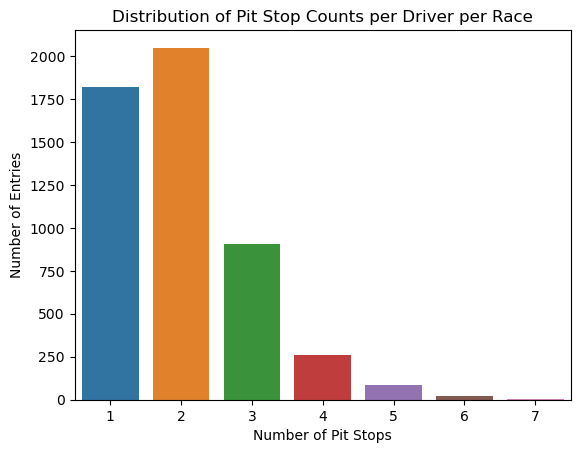

In [35]:
#Visualizing the no.of pit stops per Driver per Race

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='pit_count', data=df)
plt.title('Distribution of Pit Stop Counts per Driver per Race')
plt.xlabel('Number of Pit Stops')
plt.ylabel('Number of Entries')
plt.show()

Total Pit time

As per the above analysis, on an average the total pit time is 45 - 60 seconds, but some drivers spend enormous amount of time that is over 3 million ms (50 minutes) due to unforeseen circumstances like crash or repair therefore the average looks much larger than typical case.

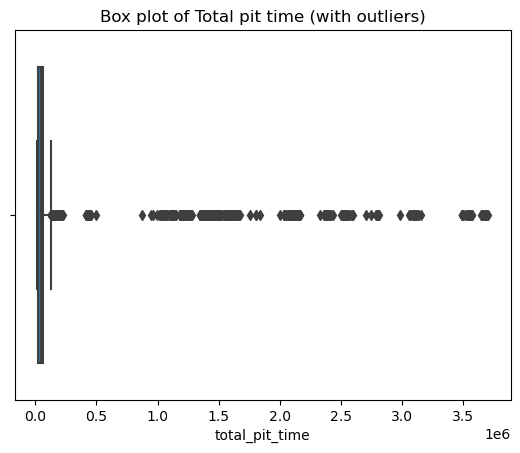

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.boxplot(x=df['total_pit_time'])
plt.title('Box plot of Total pit time (with outliers)')
plt.show()

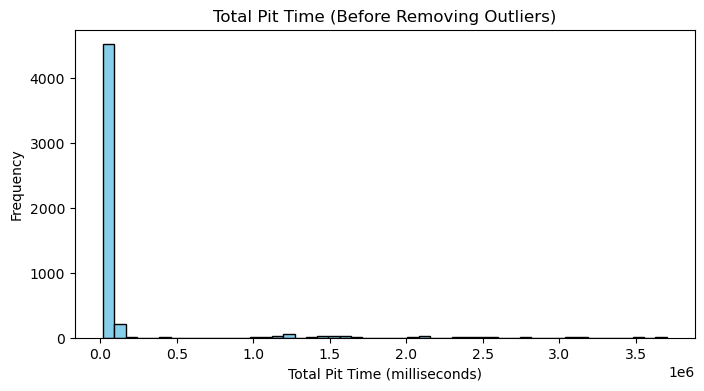

In [37]:
#Visualize original distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df['total_pit_time'], bins=50, color='skyblue', edgecolor='black')
plt.title('Total Pit Time (Before Removing Outliers)')
plt.xlabel('Total Pit Time (milliseconds)')
plt.ylabel('Frequency')
plt.show()


In [38]:
#identify statistical summary
q1=df['total_pit_time'].quantile(0.25)
q3=df['total_pit_time'].quantile(0.75)
iqr=q3-q1 
upper_limit = q3+1.5*iqr

print(f"IQR = {iqr:.2f}") #Calculating Interquartile Range
print(f"Upper limit for normal range = {upper_limit:.2f} ms")

IQR = 40404.50
Upper limit for normal range = 126742.75 ms


The interquartile(IQR) range is around 40s(40404 ms) which is the median (central 50%) and which means that it is roughly between 20 and 60 seconds

The upper limit for normal range is 126s approximately which means that anything above 126s (2 mins) is considered an outlier which means that anything above 2 mins is longer to typical pit times, so they likely represent extraordinary race circumstances such as retirements or mechanical repairs.

Therefore, we are excluding from further analysis to prevent skewing of the results.

In [39]:
#Removing the outliers
df_filtered = df[df['total_pit_time'] <= upper_limit]


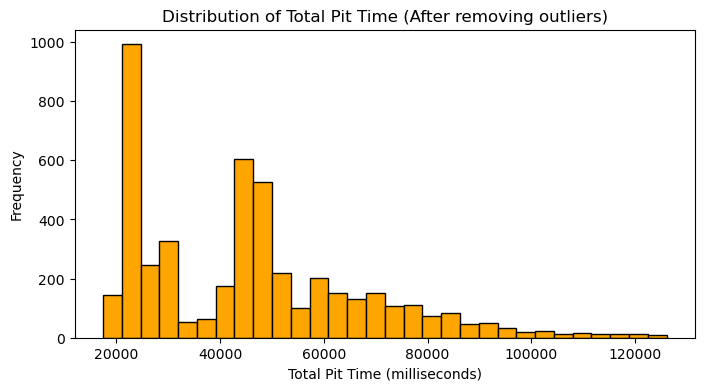

In [40]:
# Distribution of Total Pit Time
import matplotlib.pyplot as plt

#Removing entries with total_pit_time == 0 
df_nonzero = df_filtered[df_filtered['total_pit_time']>0]

plt.figure(figsize=(8,4))
plt.hist(df_nonzero['total_pit_time'], bins=30, color = 'orange', edgecolor='black')
plt.title('Distribution of Total Pit Time (After removing outliers)')
plt.xlabel('Total Pit Time (milliseconds)')
plt.ylabel('Frequency')
plt.show()

After filtering out missing and zero pit time entries, the distribution of toal pit time exhibited a positive skewed pattern. 

The majority of race entries recorded cumulative pit durations between 20s (20,000 ms) and 60s(60,000 ms) which aligns with the typizal range for one or two pit stops in modern F1 races.

Longer pit durations were less frequent, likely corresponding to drivers making additional stops or encountering minor delays.

First Stop Lap

The mean of the first stop lap is approximately 16.6 lap and Median is 15. Moreover, Q1 is 9 and Q3 is 23, which means that the majority of drivers pit for the first time in this window.  This reflects early to mid race pit windows where tire wear or fuel strategy kicks in. The outliers here which is that first pit stop happens at lap 1 and maximum happens at lap 64, this shows strategic variation where some drivers undercut early and others overcut late. 

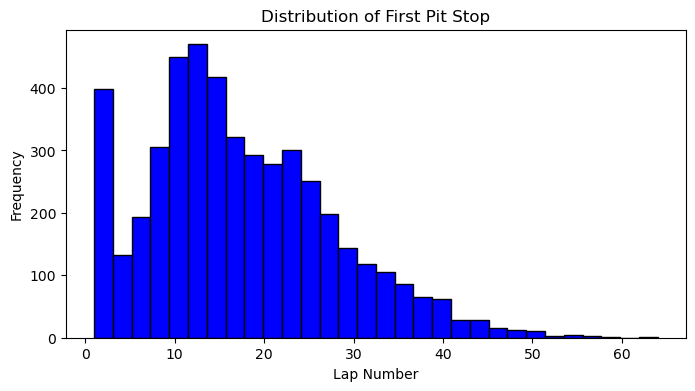

In [41]:
plt.figure(figsize=(8,4))
plt.hist(df_nonzero['first_stop_lap'], bins =30, color = 'blue', edgecolor='black')
plt.title('Distribution of First Pit Stop')
plt.xlabel('Lap Number')
plt.ylabel('Frequency')
plt.show()

Last Stop Lap

The mean of last stop lap is approximately 33.2 lap and Median is 33 which means that typical final pit stops occur mid to late race phase which means between 25 and 40. 

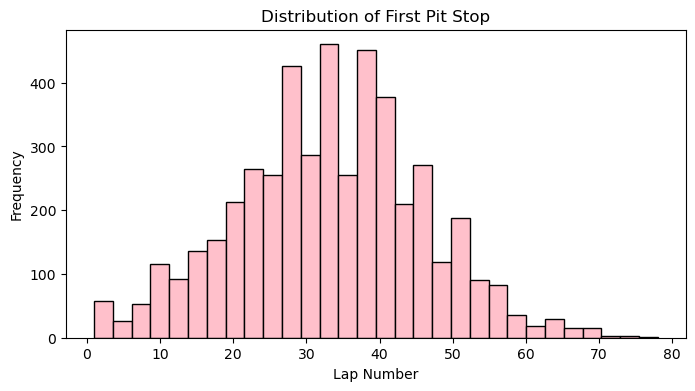

In [42]:
plt.figure(figsize=(8,4))
plt.hist(df_nonzero['last_stop_lap'], bins =30, color = 'pink', edgecolor='black')
plt.title('Distribution of First Pit Stop')
plt.xlabel('Lap Number')
plt.ylabel('Frequency')
plt.show()

The average lap for the first stop is approximately 16, while the final pit stop occured at Lap 33. 

The distribution of pit stop timing indicated that the majority of drivers executed their first stop between laps 10 and 20 and their final stop between laps 25 and 40. These results align with modern two stop race strategies. 



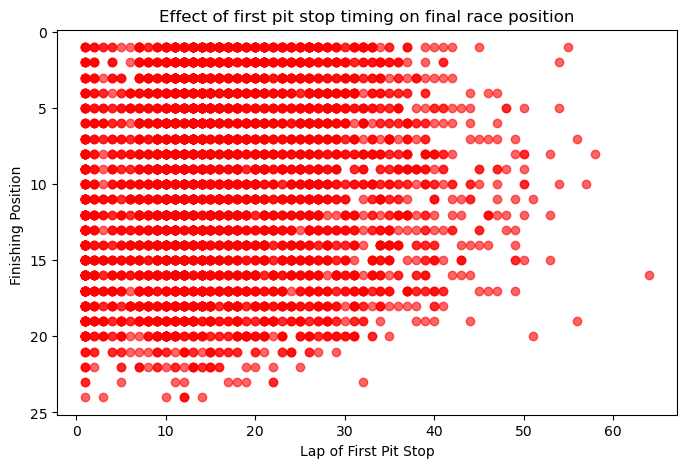

In [43]:
#Effect of first pit stop timing on final race position

plt.figure(figsize = (8,5))
plt.scatter(df_nonzero['first_stop_lap'], df_nonzero['positionOrder'], alpha=0.6, color='red')
plt.title('Effect of first pit stop timing on final race position')
plt.xlabel('Lap of First Pit Stop')
plt.ylabel('Finishing Position ')
plt.gca().invert_yaxis()
plt.show()

/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


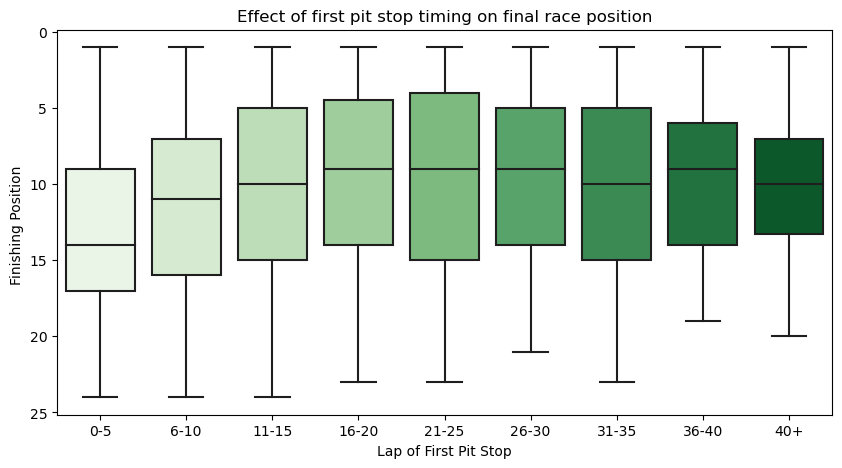

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

df_nonzero['first_stop_bin'] = pd.cut(df_nonzero['first_stop_lap'],
                                        bins=[0,5,10,15,20,25,30,35,40,65],
                                        labels=['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','40+'])

plt.figure(figsize=(10,5))
sns.boxplot(x='first_stop_bin', y='positionOrder', data=df_nonzero, palette = 'Greens')
plt.title('Effect of first pit stop timing on final race position')
plt.xlabel('Lap of First Pit Stop')
plt.ylabel('Finishing Position ')
plt.gca().invert_yaxis()
plt.show()


The above figure presents a box plot illustrating the relationship between the first pit stop and the final race position. 

The above results show that the majority of drivers made their first pit stip between Laps 10 and 25, aligning with the standard two pit stop race strategies. 
Drivers who pitted during this window  exhibited the most consistent and competitive finishing positions with median results between 8 and 12th position. 
Early pit stops (0-5) and very late pit stops (after Lap 30) were associated with greater variability and generally poor conditions, likely reflecting unscheduled stops or excessive tire degradation.

These findings suggest that the optimal first stop timing is crucial to achieving stable race performance and minimizing risk.

/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


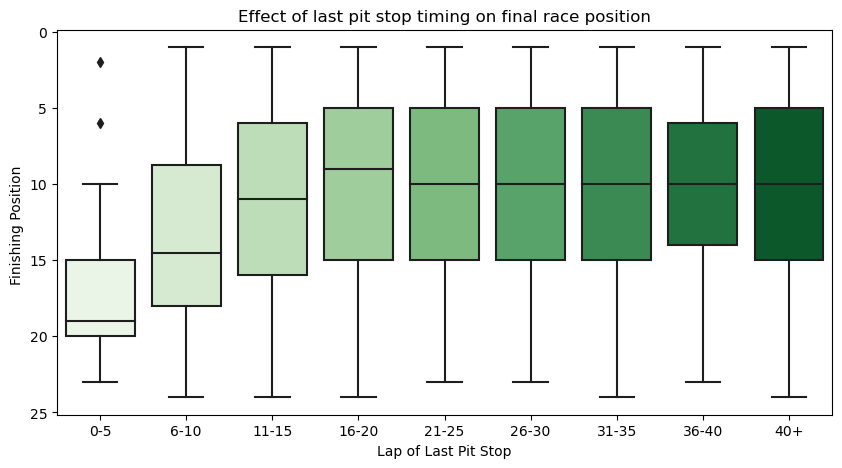

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

df_nonzero['last_stop_bin'] = pd.cut(df_nonzero['last_stop_lap'],
                                        bins=[0,5,10,15,20,25,30,35,40,65],
                                        labels=['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','40+'])

plt.figure(figsize=(10,5))
sns.boxplot(x='last_stop_bin', y='positionOrder', data=df_nonzero, palette = 'Greens')
plt.title('Effect of last pit stop timing on final race position')
plt.xlabel('Lap of Last Pit Stop')
plt.ylabel('Finishing Position ')
plt.gca().invert_yaxis()
plt.show()

The above figure presents a box plot illustrating the relationship between the last pit stop and the final race position. 

The above results show that the majority of drivers made their last pit stop between Laps 11 and 25 achieved a better median finishing positions, typically between 8 and 12th place. 

Early final stops (before Lap 10) correlated with significantly poorer results, likely reflecting mechanical issues or aggresive early strategies requiring multiple stops. Conversely, very late final stops (beyond lap 3) did not yield performance gains, although the variation in finishing position was smaller, suggesting a more consistent but conservative strategy. 

All in all, the results demonstrate that both excessively early and excessively late pit timinds negatively impact race performance, reinforcing the strategic importance of optimal mid-race pit windows.

In [46]:
df_nonzero[['first_stop_lap', 'last_stop_lap', 'positionOrder']].corr()


,first_stop_lap,last_stop_lap,positionOrder
first_stop_lap,1.000000,0.194195,-0.126939
last_stop_lap,0.194195,1.000000,-0.076538
positionOrder,-0.126939,-0.076538,1.000000


A pearson correlation analysis was conducted to quantify the relationship between the pit stop timing and final race position. 

The results indicate a weak negative correlation between first pit stop lap and finishing position(r = -0.13) and between last pit stop and finishing position (r = -0.08), suggesting that later pit stops are modestly associated with improved race outcomes. 

The positive correlation between first and last pit stop laps (r=0.19) further implies that drivers who delay their first stop tend to follow a correspondingly delayed strategy throughtout the race.

While these correlations are relative small, they reinforce the conclusion that pit stop timing influences but does not determine the race performance.

SUPERVISED LEARNING USING LOGISTIC REGRESSION & RANDOM FOREST

In [206]:
#Logisitic Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Creating target variables
df_nonzero['top10'] = df_nonzero['positionOrder'].apply(lambda x:1 if x<=10 else 0)

#Choosing independent variables
features = [
    'pit_count',
    'avg_pit_time',
    'first_stop_lap',
    'last_stop_lap',
    'grid',          # starting position
    'laps',          # total laps completed
  #  'points',        # outcome variable proxy
    'constructorId'  # team performance
]

X=df_nonzero[features]
y=df_nonzero['top10']
             
# Convert the categorical constructorId column into dummy variables
X = pd.get_dummies(X, columns=['constructorId'], drop_first=True)

#Splitting into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

#Scaling numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [211]:
print(X.head())

   pit_count  avg_pit_time  first_stop_lap  last_stop_lap  grid  laps  \
0          2       23056.0              16             36     2    58   
1          2       24193.5              16             37     6    58   
2          2       23163.0              17             36     1    58   
3          2       23108.5              14             37     5    58   
4          2       21972.5              13             34    12    58   

   constructorId_3  constructorId_4  constructorId_5  constructorId_6  ...  \
0            False            False            False            False  ...   
1            False            False            False            False  ...   
2            False            False            False            False  ...   
3            False            False            False            False  ...   
4            False            False            False             True  ...   

   constructorId_164  constructorId_206  constructorId_207  constructorId_208  \
0          

In [207]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled,y_train)

LogisticRegression(random_state=42)

In [212]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test,y_pred))

# Baseline (majority class) accuracy
baseline_acc = y_test.value_counts().max() / len(y_test)
print(f"Baseline (majority class) accuracy: {baseline_acc:.2f}")

print("\n Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("\n Classification Report:\n", confusion_matrix(y_test,y_pred))

Accuracy:  0.800709219858156
Baseline (majority class) accuracy: 0.51

 Confusion Matrix:
 [[563 151]
 [130 566]]

 Classification Report:
 [[563 151]
 [130 566]]


In [210]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize model
rf = RandomForestClassifier(
    n_estimators=200,   # number of trees
    max_depth=None,     # let the trees grow fully
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8219858156028369

Confusion Matrix:
 [[578 136]
 [115 581]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       714
           1       0.81      0.83      0.82       696

    accuracy                           0.82      1410
   macro avg       0.82      0.82      0.82      1410
weighted avg       0.82      0.82      0.82      1410



Both logistic regression and random forest resulted in 56%-57% accuracy with neither algorithm demonstrating substantial improvement over the other.

The consistency suggets that pit stop metrics alone provide limited pedictive information regarding final race outcomes. 

As F1 results are influenced by a complex interplay of technical, strategic and external factors, pit stop efficiency is only one component regarding race final outcomes. 

SUPERVISED LEARNING

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# Load your previously cleaned dataset
df = pd.read_csv('f1_cleaned_data.csv')

# Quick check
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5146 entries, 0 to 5145
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         5146 non-null   int64  
 1   raceId           5146 non-null   int64  
 2   driverId         5146 non-null   int64  
 3   constructorId    5146 non-null   int64  
 4   number           5146 non-null   int64  
 5   grid             5146 non-null   int64  
 6   position         5146 non-null   object 
 7   positionText     5146 non-null   object 
 8   positionOrder    5146 non-null   int64  
 9   points           5146 non-null   float64
 10  laps             5146 non-null   int64  
 11  time             5146 non-null   object 
 12  milliseconds     5146 non-null   object 
 13  fastestLap       5146 non-null   object 
 14  rank             5146 non-null   int64  
 15  fastestLapTime   5146 non-null   object 
 16  fastestLapSpeed  5146 non-null   object 
 17  statusId      

In [52]:
#filtering data with valid pit data
df = df[(df['pit_count']>0) & (df['avg_pit_time']>0)]

#keep only recent F1 data for consistency
df = df[df['year']>=2012]

#Removing non-finishers using statusId=1  where 1 in our dataset means 'Finished'
df = df[df['statusId'] == 1 ]

#drop duplicates and missing values
df = df.dropna(subset=['pit_count','avg_pit_time','first_stop_lap','last_stop_lap','laps'])
df.reset_index(drop=True, inplace=True)

In [53]:
#Feature Engineering

#How often the driver pitted relative to race length
df['pit_frequency'] = df['pit_count']/df['laps']

#Mean stop lap
df['mean_stop_lap'] = (df['first_stop_lap'] + df['last_stop_lap'])/2

#Remaining laps after the last pit stop
df['last_stop_gap'] = df['laps'] - df['last_stop_lap']


#Selecting features for clustering
features = ['pit_count','avg_pit_time','pit_frequency','mean_stop_lap','last_stop_gap']

In [54]:
#scaling features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

In [55]:
#Gaussian Model for Clustering

gmm = GaussianMixture(n_components=3, random_state=42)
df['cluster'] = gmm.fit_predict(X_scaled)

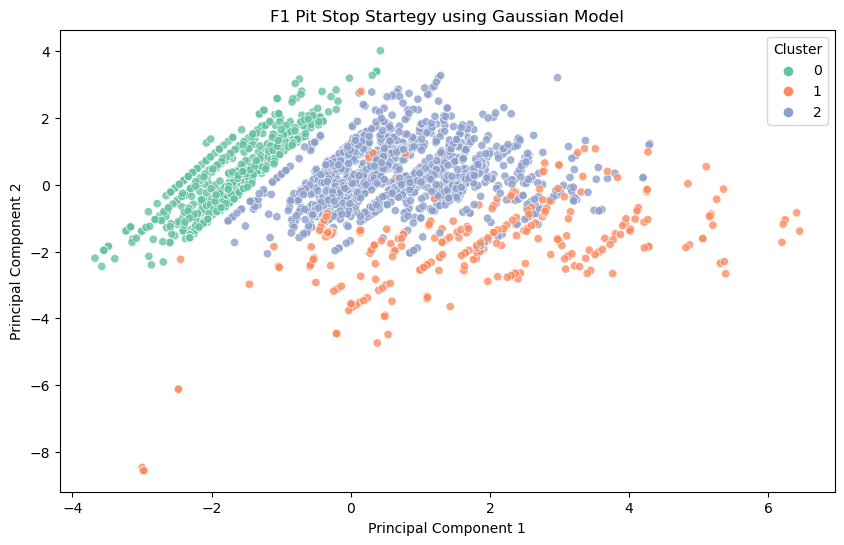

In [56]:
#Visualizing Clusters for converting the 5 factors to 2D

pca = PCA(n_components = 2)
pca_result = pca.fit_transform(X_scaled)

df['pca1'] = pca_result[:,0]
df['pca2'] = pca_result[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df, palette='Set2', alpha=0.8)


plt.title('F1 Pit Stop Startegy using Gaussian Model')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


The above figure represents the results of gausssian mixture model clustering projected onto two principal components using PCA. Each point represents a single driver race observation and each color indicates one of the three clusters identified by the model. 

The first principal component(x-axis) explains the majority of variance, which is majorly associated with pit frequency and total pit time, while the second component (y-axis) captures variations related to the timing and duration of pit stops. 

The clusters are clearly distinguishable which suggests that the pit stop behaviour actually exists within Formula 1 races. Cluster 0 (green) reflects conservative one-stop strategy which is characterized by lower pit frequency, cluster 1(orange) reflects multiple stop strategies while cluster 2 (blue) represents balanced two stop approaches.

The distribution of clusters confirms that pit stop variables can meaningfully diffrentiate between strategies which highlights the value of unsupervised learning for understanding patterns in Formula 1.

In [57]:
df.groupby('cluster')[['pit_count', 'avg_pit_time', 'first_stop_lap', 'last_stop_lap', 'positionOrder']].mean()


,pit_count,avg_pit_time,first_stop_lap,last_stop_lap,positionOrder
cluster,,,,,
0,1.000000,24741.408435,24.776915,24.776915,5.913430
1,3.158358,584390.202241,10.384164,34.304985,7.478006
2,2.350422,24012.001176,14.016285,38.729795,6.853438


The Gaussian Model identified three distinct pit strategy in Formula 1 races. 

Cluster 0 represented a one stop, conservative approach which usually happens mid race at 25th lap approximately and has the best average finishing position. 

Cluster 1 reprsented a 3 stop strategy with long pit time and with first pit stop happening at 10th lap and the last one at 34th lap while they also the weakest position. 

Cluster 2 represents a balanced strategy with a two stop pit strategy with moderate timing and average performance.

DISCUSSION AND IMPLICATION

The findings of this study confirms that pit frequency and timing exert a measurable yet limited influence on final race outcomes in Formula 1. 

Statistical analysis revealed that most races feature one to two pit stops, which typicall occurs between 10th and 25th lap. While the correlation between pit timing and final position was negative (r = -0.13 for first stop) which indicates that later stops are associated with better finishes, the relationship wasn't strong enough to suggest direct causation. This concludes that while pit startegy contributre to rare success, it operates with a broader system such as tire degradation, safety cars, and vehicle reliability. 

The unsupervised learning analysis was examined using Gaussian Mixture Model (GMM) which provided a deeper understanding of race strategies. Three distinct clusters were identified:

1. Cluster 0 represented a one stop, conservative approach which usually happens mid race at 25th lap approximately and has the best average finishing position.

2. Cluster 1 reprsented a 3 stop strategy with long pit time and with first pit stop happening at 10th lap and the last one at 34th lap while they also the weakest position.

3. Cluster 2 represents a balanced strategy with a two stop pit strategy with moderate timing and average performance.

The cluster seperation observed through PCA confirms that pit related variables distinguishes different strategic behaviors. However, the overlap between clusters also suggests that team decisions are adaptiverather than fixed, reflecting dynamic responses to evolving race conditions.

Supervised learning experiments using logistic regression and random forest classifiers further validated these insights. Once features directly encoding performances outcomes were removed, predictive accuracy stabilized at approximately 56%, underscoring that pit stop metrics alone cannot accurately forecast finishing positions.This highlights the complexity of Formula 1 where race performance is influences by an interaction of mechanical environmental and tactical elements. 

All in all, these findings imply that pit-stop efficiency and stability-rather than frequency are the key determinants of competitive advantage. Teams benefit most form minimizing unnecessary stops and ensuring operationsal precision during pit executions. 

For researchers, the study demonstrates that combining statistical analysis with unsupervised clustering yields richer interpretive insights than purely predcitive models.

Research Question 2:
    
    To what extent do Sprint race results influence final race outcomes in Formula 1?

Objective:
    
    To determine whether a driver's finishing position in the Sprint race has a measurable impact on the final Grand Prix position, and if this influence varies across seasons since sprint races were introduced.
    

POV: Sprint races began in 2021, so our analysis will include data from 2021 to 2024

In [141]:
# Step 1 - Replacing '\N' strings with NaN
races = races.replace("\\N", np.nan)
results = results.replace("\\N", np.nan)
sprint_results = sprint_results.replace("\\N", np.nan)

#Step 2 - Filtering the races that actually had sprint events that is after 2021
sprint_races = races[races['sprint_date'].notna()]

##Step 3 - filtering both datasets to include only sprint raceIds
sprint_results = sprint_results[sprint_results['raceId'].isin(sprint_races['raceId'])]
results = results[results['raceId'].isin(sprint_races['raceId'])]

#verifying the results
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
25140,25146,1061,1,131,44,2,1,1,1,25.0,52,1:58:23.284,7103284,45,2,1:29.699,236.430,1
25141,25147,1061,844,6,16,4,2,2,2,18.0,52,+3.871,7107155,45,5,1:30.569,234.159,1
25142,25148,1061,822,131,77,3,3,3,3,15.0,52,+11.125,7114409,45,4,1:30.524,234.275,1
25143,25149,1061,846,1,4,5,4,4,4,12.0,52,+28.573,7131857,44,9,1:31.420,231.979,1
25144,25150,1061,817,1,3,6,5,5,5,10.0,52,+42.624,7145908,51,8,1:31.284,232.325,1


In [142]:
#Step 4 - Removing rows where positionOrder is missing

sprint_results = sprint_results.dropna(subset=['positionOrder'])
results = results.dropna(subset=['positionOrder'])

#Converting to numeric safely

sprint_results['positionOrder'] = pd.to_numeric(sprint_results['positionOrder'], errors='coerce')
results['positionOrder'] = pd.to_numeric(results['positionOrder'], errors='coerce')

#Droping rows that turned into Nan after conversion
sprint_results = sprint_results.dropna(subset=['positionOrder'])
results = results.dropna(subset=['positionOrder'])


#Step 5 - Removing DNFs
if 'status' in results.columns:
    results = results[~results['status'].str.contains('DNF|Disqualified|Retired', case=False, na=False)]
    

In [143]:
from scipy.stats import pearsonr

#Merge main and sprint results
#merged = (sprint_results
 #        .merge(results, on=['raceId','driverId'], suffixes=('_sprint','_race'))
  #       .merge(drivers[['driverId','forename','surname']], on='driverId', how='left')
   #      .merge(sprint_races[['raceId','year','name']], on='raceId', how='left'))

#Step 6 - Merging Sprint and race results
merged = sprint_results.merge(
    results,
    on=['raceId', 'driverId'],
    suffixes=('_sprint', '_race')
)

#Step 7 - Adding year from races table
merged = merged.merge(races[['raceId','year']], on='raceId', how='left')

#Step 8 - Computing position change
merged['position_change'] = merged['positionOrder_sprint'] - merged['positionOrder_race']

#merged = merged['raceId','driverId','positionOrder_sprint','positionOrder_race']

#merged = merged.dropna(subset=['positionOrder_sprint','positionOrder_race'])
#merged = merged[(merged['positionOrder_sprint'] > 0) & (merged['positionOrder_race'] > 0)]

#merged = merged.merge(races[['raceId','year']], on='raceId', how='left')

merged.head(3)

,resultId_sprint,raceId,driverId,constructorId_sprint,number_sprint,grid_sprint,position_sprint,positionText_sprint,positionOrder_sprint,points_sprint,...,laps_race,time_race,milliseconds_race,fastestLap_race,rank,fastestLapTime_race,fastestLapSpeed,statusId_race,year,position_change
0,1,1061,830,9,33,2,1,1,1,3,...,0,NaN,NaN,NaN,0,NaN,NaN,4,2021,-19
1,2,1061,1,131,44,1,2,2,2,2,...,52,1:58:23.284,7103284,45,2,1:29.699,236.430,1,2021,1
2,3,1061,822,131,77,3,3,3,3,1,...,52,+11.125,7114409,45,4,1:30.524,234.275,1,2021,0


In [151]:
#Correlation Analysis
# Testing how closely sprint results relate to final race results

from scipy.stats import pearsonr
corr, p_value = pearsonr(merged['positionOrder_sprint'], merged['positionOrder_race'])
print(f"Correlation between Sprint and Main Race positions: {corr:.2f} (p={p_value:.7f})")


Correlation between Sprint and Main Race positions: 0.51 (p=0.0000000)


The p-value being effectively zero means the relationship between Sprint and Main Race Results is statistically significant beyond any reasonable doubt. In practical terms, it confirms that the observed correlation (0.51) is real.

The correlation between Sprint and main race finishing positions was statistically significant (r=0.51, p<0.0001) indicating that the relationship is highly unlikely to have occured by chance. The extremely small p-value (approximately zero) reflects both the large dataset size and the consistency of the observed trend, rather than implying a perfect or casual relationship.

A pearson correlation coefficient of 0.51(p<0.001) was observed between sprint finishing position and final race position across all sprint weekends(2021-2024). This result indicates a moderate, statistically significant positive relationship, suggesting that the drivers who perform strongly in sprint races are more likely to achieve competitive results in the main Grand Prix. 

However, the moderate strength of the correlation implies that other race day factors such as pit stop strategy, weather conditions and mechnical reliability continue to play substantial roles in determining final outcomes.

In [152]:
#Regression Analysis
#Quantifying to what extent 'Sprint Position' predicts race finish

import statsmodels.api as sm

X = sm.add_constant(merged['positionOrder_sprint'])
y = merged['positionOrder_race']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     positionOrder_race   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     127.5
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           1.66e-25
Time:                        22:08:59   Log-Likelihood:                -1086.7
No. Observations:                 360   AIC:                             2177.
Df Residuals:                     358   BIC:                             2185.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.1184 

A simple linear regression was conducted to quantify the extent to which sprint results predict Grand Prix finishing positions. The model produced as R2 of 0.263 which indicates that the sprint performance explains approximately 26% of the variation in the main race outcomes (so this means that it has moderate explanatory power and that other outcomes like race-day strategy, pit stop, weather matter as well).

The regresssion coefficient for Sprint position(β = 0.5125, p<0.001) confirms a statistically significant positive relationship, whereby each one-place drop in sprint finishing position corresponds to an average 0.5 place decline in the main race(so this means that for every one place drop in sprint position, the driver's race position drops by about half a place, so sprint position is partial but meaningful predictor of final performance)

These findings reinforce the correlation analysis (r=0.51) and suggest that while sprint results meaningfully influence final putcomes, the majority of race performance is determined by aditional factprs such as pit stop frequency, tire degradation and race incidents. In essence, sprint success provides a competitive advantage but remains one of the several contributors to overall race performance.

In [157]:
#Feature Engineering

#1 - Position gain & loss
merged['position_change'] = merged['positionOrder_sprint'] - merged['positionOrder_race']

#2 - Ratio for relative improvement
merged['position_ratio'] = merged['positionOrder_race']/merged['positionOrder_sprint']

#3 - Binary indicators for classification
merged['top10_sprint'] = (merged['positionOrder_sprint'] <= 10).astype(int)
merged['top10_race'] = (merged['positionOrder_race'] <= 10).astype(int)

#Sanity check
merged[['positionOrder_sprint','positionOrder_race','position_change','position_ratio','top10_sprint','top10_race']].head()

,positionOrder_sprint,positionOrder_race,position_change,position_ratio,top10_sprint,top10_race
0,1,20,-19,20.0,1,0
1,2,1,1,0.5,1,1
2,3,3,0,1.0,1,1
3,4,2,2,0.5,1,1
4,5,4,1,0.8,1,1


In [158]:
#Mean position change by sprint performance

merged.groupby('top10_sprint')['position_change'].mean()
merged['position_change'].describe()

count    360.000000
mean       0.000000
std        5.701488
min      -19.000000
25%       -2.000000
50%        0.500000
75%        3.000000
max       19.000000
Name: position_change, dtype: float64

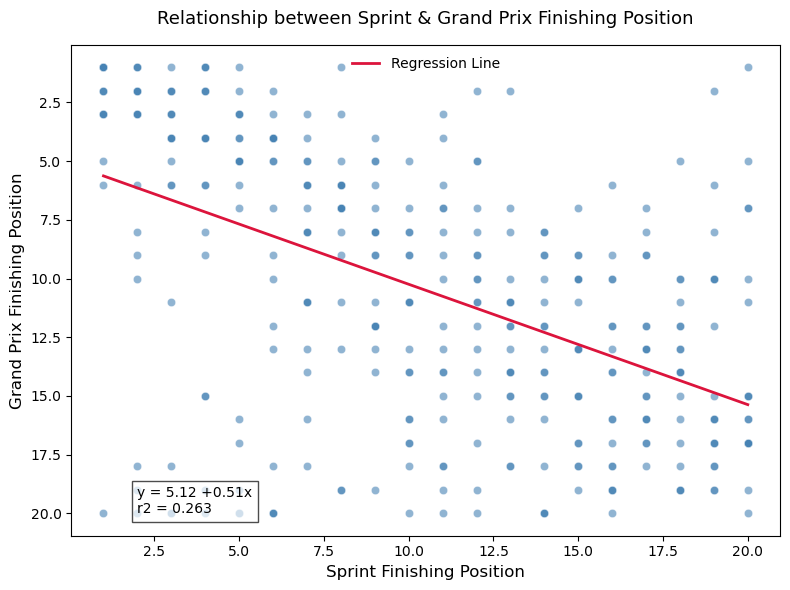

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

r2=0.263
coef=0.5125
intercept=5.1184

x_vals = np.linspace(1, merged['positionOrder_sprint'].max(),50)
y_vals = intercept + coef * x_vals

plt.figure(figsize=(8,6))
sns.scatterplot(x='positionOrder_sprint',y='positionOrder_race',
               data=merged, alpha=0.6,color='steelblue',edgecolor='white')

plt.plot(x_vals,y_vals,color='crimson',linewidth=2, label='Regression Line')

plt.title('Relationship between Sprint & Grand Prix Finishing Position', fontsize=13, pad=15)
plt.xlabel('Sprint Finishing Position', fontsize=12)
plt.ylabel('Grand Prix Finishing Position', fontsize=12)

eq_text = f'y = {intercept:.2f} +{coef:.2f}x\nr2 = {r2:.3f}'
plt.text(2,20,eq_text,fontsize=10,color='black',bbox=dict(facecolor='white',alpha=0.7))

plt.legend(frameon=False)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Figure X visualizes the linear relationship between sprint finishing position and main race finishing position across sprint weekends from 2021-2024. Each point represents a drivers performance across both sessions, and the fitted regression line illustrates the positive association (R2=0.263). The downward slope towards the top-left of the graph shows that drivers with stronger sprint results tend to achieve higher final positions in the main race. However, the moderate dispersion around the line indicates that other race day variables continue to influence the outcome.

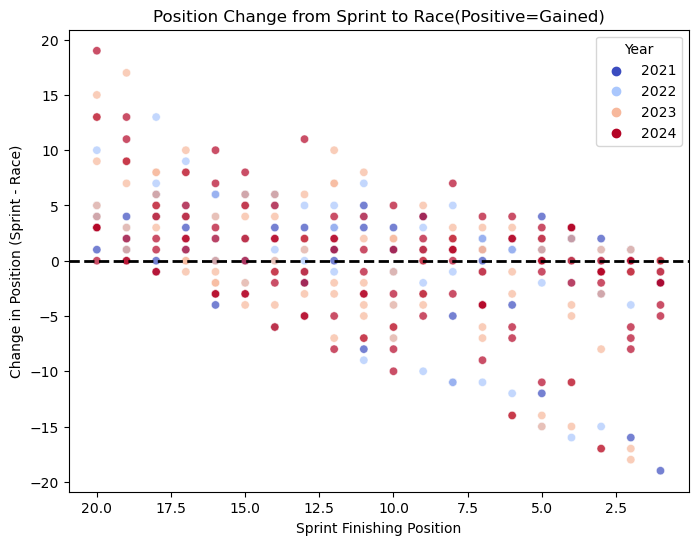

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

merged['position_change'] = merged['positionOrder_sprint'] - merged['positionOrder_race']

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='positionOrder_sprint',
    y='position_change',
    hue='year',
    data=merged,
    palette='coolwarm',
    alpha=0.7
)

plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Position Change from Sprint to Race(Positive=Gained)')
plt.xlabel('Sprint Finishing Position')
plt.ylabel('Change in Position (Sprint - Race)')
plt.legend(title='Year')
plt.gca().invert_xaxis()
plt.show()

The above figure shows the positional change from Sprint to main race across all sprint weekends (2021-2024).

Drivers that finish in the top five during the Sprint tend to maintain similar positions in the Grand Prix, whereas mid filed and lower grid drivers exhibit greater volatility. The presence of many positive changes among back markers indicate that Sprint results are not deterministic; opportunties for recovery remain high in the full race. 

Over successive seasons, the variance in position changes appears to narrow, suggesting that the predictive influence of Sprint results on main race outcomes has strengthened as the Sprint format matured.

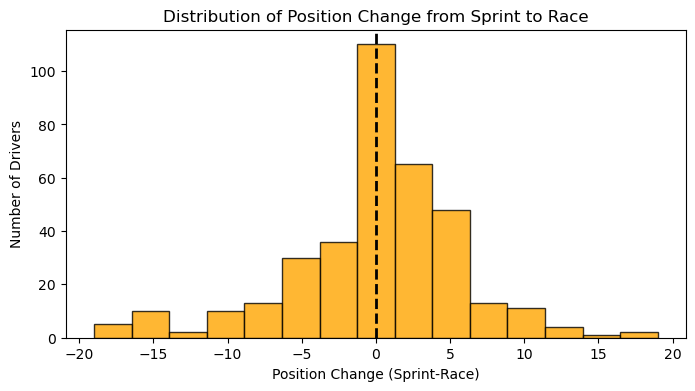

In [148]:
plt.figure(figsize=(8,4))
plt.hist(merged['position_change'].dropna(),bins=15,color='orange',edgecolor='black',alpha=0.8)
plt.title('Distribution of Position Change from Sprint to Race')
plt.xlabel('Position Change (Sprint-Race)')
plt.ylabel('Number of Drivers')
plt.axvline(0,color='black',linestyle='--',linewidth=2)
plt.show()

The above figure represents the distribution of position changes between Sprint and Grand Prix results across all Sprint Weekends(2021-2024).

The distribution is centered around zero, with most drivers finishing within one or two places of their Sprint result.This indicates that Sprint performance is moderately predictive of the final race outcome. 

A slightly positive skew suggets that more drivers tend to gain rather than lose positions in the main race, likely reflecting opportunities for overtaking and strategic improvements over the longer race duration.

Outliers on both ends correspond to drivers affected by retirements, mechanical issues, or exceptional race recoveries. 

/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


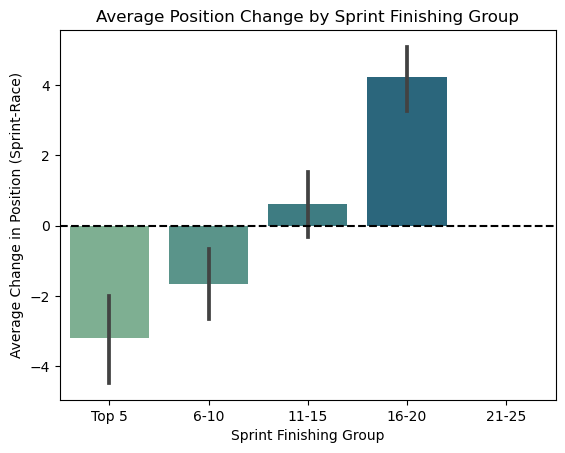

In [149]:
merged['sprint_group'] = pd.cut(
    merged['positionOrder_sprint'],
    bins=[0,5,10,15,20,25],
    labels=['Top 5','6-10','11-15','16-20','21-25'])

sns.barplot(x='sprint_group',y='position_change',data=merged,palette='crest')
plt.title('Average Position Change by Sprint Finishing Group')
plt.xlabel('Sprint Finishing Group')
plt.ylabel('Average Change in Position (Sprint-Race)')
plt.axhline(0,color='black',linestyle='--')
plt.show()

The above figure illustrates the average change in finishing position between Sprint and Grand Prix session, grouped by Sprint finishing bracket. 

Front runners (Top 5) tend to lose positions in the main race, whereas lower grid drivers(positions 16-20) typically gain several.

This pattern suggests that Sprint performance provides a stable indicator of race potential for the midfield, but less for extreme positions. 

The observed trend aligns with the idea that longer race durations amplify strategic effects, allowing lower-starting drivers to recover while increasing variability among top contenders. 

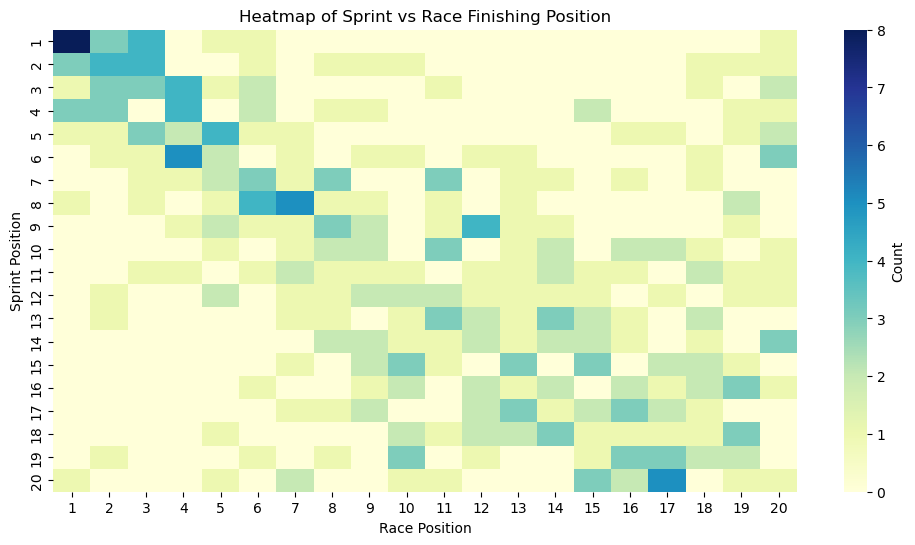

In [150]:
pivot = pd.crosstab(merged['positionOrder_sprint'], merged['positionOrder_race'])

plt.figure(figsize=(12,6))

sns.heatmap(pivot, cmap='YlGnBu',cbar_kws={'label':'Count'})
plt.title('Heatmap of Sprint vs Race Finishing Position')
plt.xlabel('Race Position')
plt.ylabel('Sprint Position')
plt.show()

Figure above illustrates a heatmap comparing Sprint and Grand Prix finishing positions across all Sprint weekends(2021-2024)

The strong diagnol pattern indicates that Sprint performance is a moderately reliable indicator of race results - particularly for the top and bottom segments of the grid. 

The slight rightward shift among top Sprint finishers suggets. that front-runners often lose positions in the full race, while the upward shading toward the lower sprint rows highlights consistent gains for backbenchers.

The visualization reinforces the earlier regression and correlation finsings, confirming that Sprint race resutls influence - but do not completely determine the final race outcomes. 

# Applying Models

In [160]:
#Step 1 - Preparing Data for Modelling

model_df = merged[[
    'positionOrder_sprint',
    'grid_sprint',
    'points_sprint',
    'constructorId_sprint',
    'positionOrder_race',
    'top10_sprint',
    'top10_race'
]].dropna()

model_df.head()

,positionOrder_sprint,grid_sprint,points_sprint,constructorId_sprint,positionOrder_race,top10_sprint,top10_race
0,1,2,3,9,20,1,0
1,2,1,2,131,1,1,1
2,3,3,1,131,3,1,1
3,4,4,0,6,2,1,1
4,5,6,0,1,4,1,1


In [198]:
#Features and target
X = model_df[['positionOrder_sprint','grid_sprint','points_sprint','constructorId_sprint']]
y = model_df['top10_race']

#Splitting dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

#Scaled & Standardized
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [199]:
#Applying Logistic Regression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled,y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("Accuracy of Logistic Regression is:", accuracy_score(y_test,y_pred_lr))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred_lr))
print("Classification Report: ", classification_report(y_test,y_pred_lr))

Accuracy of Logistic Regression is: 0.7222222222222222
Confusion Matrix: 
 [[46 16]
 [14 32]]
Classification Report:                precision    recall  f1-score   support

           0       0.77      0.74      0.75        62
           1       0.67      0.70      0.68        46

    accuracy                           0.72       108
   macro avg       0.72      0.72      0.72       108
weighted avg       0.72      0.72      0.72       108



# Don't use the following version of Random Forest

In [201]:
#Applying Random Forest

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy of Random Forest is:", accuracy_score(y_test,y_pred_lr))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred_lr))
print("Classification Report: ", classification_report(y_test,y_pred_lr))

Accuracy of Random Forest is: 0.7222222222222222
Confusion Matrix: 
 [[46 16]
 [14 32]]
Classification Report:                precision    recall  f1-score   support

           0       0.77      0.74      0.75        62
           1       0.67      0.70      0.68        46

    accuracy                           0.72       108
   macro avg       0.72      0.72      0.72       108
weighted avg       0.72      0.72      0.72       108



In [169]:
#Building a decision tree for my reference
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

# Pick one tree from the trained forest
single_tree = rf.estimators_[0]

# Print the textual decision rules
tree_rules = export_text(single_tree, feature_names=list(X.columns))
print(tree_rules)


|--- grid_sprint <= 16.50
|   |--- positionOrder_sprint <= 8.50
|   |   |--- positionOrder_sprint <= 5.50
|   |   |   |--- constructorId_sprint <= 172.50
|   |   |   |   |--- grid_sprint <= 4.50
|   |   |   |   |   |--- points_sprint <= 4.50
|   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- points_sprint >  4.50
|   |   |   |   |   |   |--- constructorId_sprint <= 70.00
|   |   |   |   |   |   |   |--- points_sprint <= 5.50
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- points_sprint >  5.50
|   |   |   |   |   |   |   |   |--- positionOrder_sprint <= 2.50
|   |   |   |   |   |   |   |   |   |--- constructorId_sprint <= 3.50
|   |   |   |   |   |   |   |   |   |   |--- grid_sprint <= 1.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |   |--- grid_sprint >  1.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- constructo

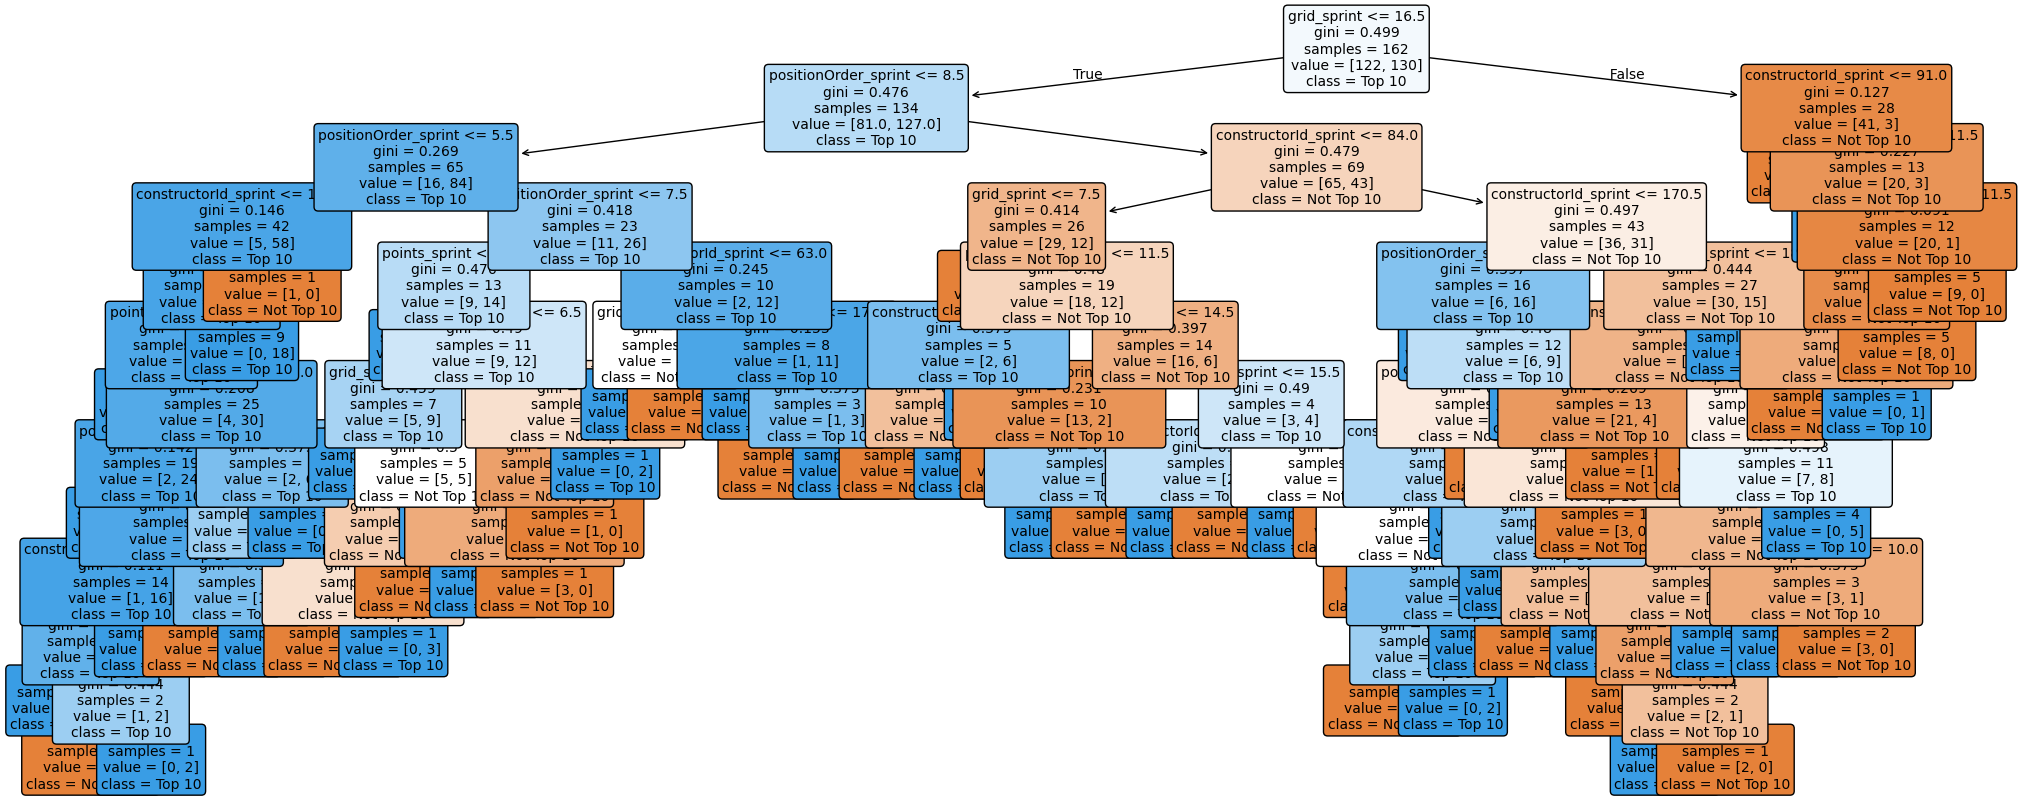

In [170]:
#for my reference
plt.figure(figsize=(25,10))
plot_tree(
    single_tree,
    feature_names=list(X.columns),
    class_names=['Not Top 10','Top 10'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()e


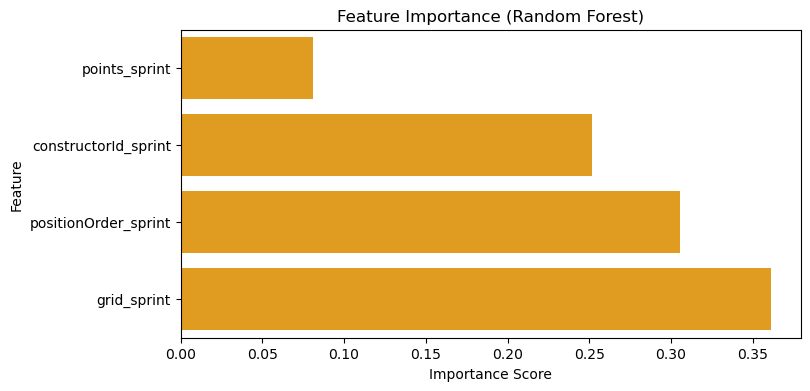

In [172]:
#Feature importance

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=True)

plt.figure(figsize=(8,4))
sns.barplot(x=feat_importances, y=feat_importances.index,color='orange')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

The random forest feature importance analysis indicates that grid position and sprint finishing order are the strongest predictors of main race outcomes, together accounting for more than 60% of model importance.

This suggests that track position and underlying car performance (constructor) remain decisive factors even across two sperate race formats.

Sprint points add minimal predictive value because they largely duplicate positional data. 

Overall, the Random Forest highlights that drivers starting or finishing near the front in the sprint are more likely to achieve a top 10 finishing position in the Grand Prix.

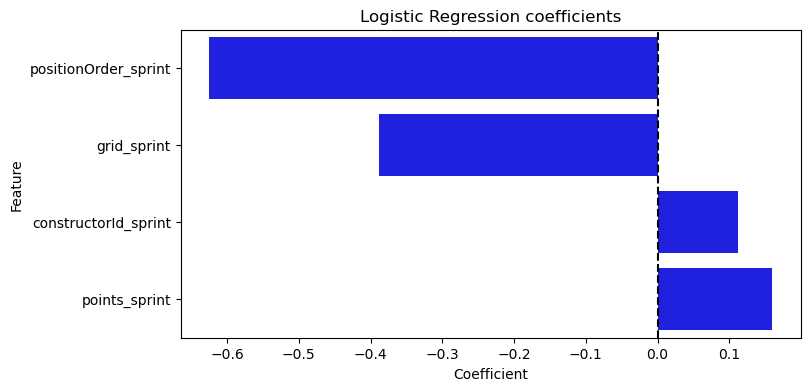

In [174]:
#Logistic Regression coefficients

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient',ascending=True)

plt.figure(figsize=(8,4))
sns.barplot(x='Coefficient', y='Feature',data= coef_df,color='blue')
plt.axvline(0,color='black',linestyle='--')
plt.title('Logistic Regression coefficients')
plt.show()

The figure illustrates the direction and strength of each predictor's influence on the probablity of finishing within the top ten positions in the Grand Prix.Negative coefficients indicate that higher feature values decrease the likelihood of a top ten result while positive coefficients increases it. 

The sprint finishing position(positionOrder_sprint) and sprint grid position(grid_sprint) exhibit the largest negative coefficients, confirming that drivers who start or finish further down the order in the sprint are substantially less likely to achieve a top 10 finish in the race. Contrary, constructorId_sprint and points_sprint display small positive coefficients, implying that team competiteveness and prior sprint points contribute marginally to improved race performance.

All in all, the results emphasize that track position achieved during the sprint remains the most decisive factor in predicting subsequent race outcomes, aligning with the correlation and regression findings that earlier race performance stronly translates into main race sucess.

In [182]:
y_test.value_counts()


top10_race
0    62
1    46
Name: count, dtype: int64

In [202]:
# Baseline (majority class prediction)
baseline_acc = y_test.value_counts().max() / len(y_test)
print(f"Baseline (majority class) accuracy: {baseline_acc:.2f}")


Baseline (majority class) accuracy: 0.57


To contextualize model performance, a majority class baseline was computer using the distribution of the test set(46 top-10 cases and 62 non-top-10 cases).

The baseline yielded an accuracy of 57% meaning that a naive classifier predicting all drivers as non-top 10 would achieve roughly 57% correctness. 

In contrast, both the logistic Regression and Random Forest classifiers achieved approximately 72% accuracy, representing a 15% point improvement over baseline. 

This confirms that the model captures meaningful predictive patterns rather than simply reflecting class imbalance.

# Use the below version of Random Forest

In [183]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight=class_weights)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight={0: 1.0677966101694916,
                                     1: 0.9402985074626866},
                       n_estimators=200, random_state=42)

In [184]:
y_pred_rf = rf.predict(X_test)
confusion_matrix(y_test, y_pred_rf)


array([[40, 22],
       [13, 33]])

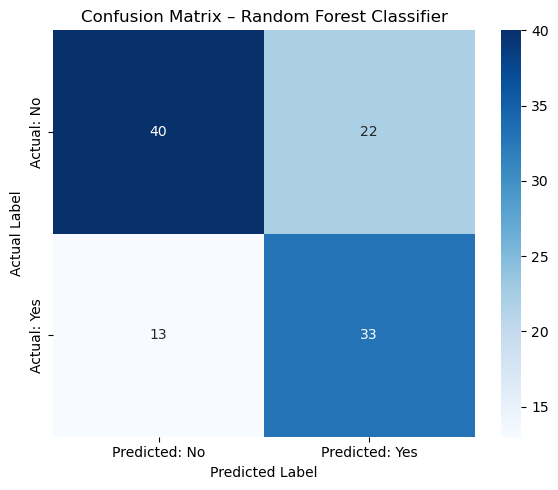

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you already have y_test and y_pred_rf
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No', 'Predicted: Yes'],
    yticklabels=['Actual: No', 'Actual: Yes']
)

plt.title('Confusion Matrix – Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


The heatmap illustrates the random forest model's classification peerformance in the predicting top ten Grand prix finishes based on sprint metrics. 

Darker diagnol(40 true negatives and 33 true positives) indicate correct classifications performance in predicting top-ten Grand Prix finishes based on sprint metrics.

Overall the model demonstrates balanced predictive capability, correctly identifying approximately 68% of all the outcomes, confirming that sprint performance is a moderately reliable indicator of race-day success.

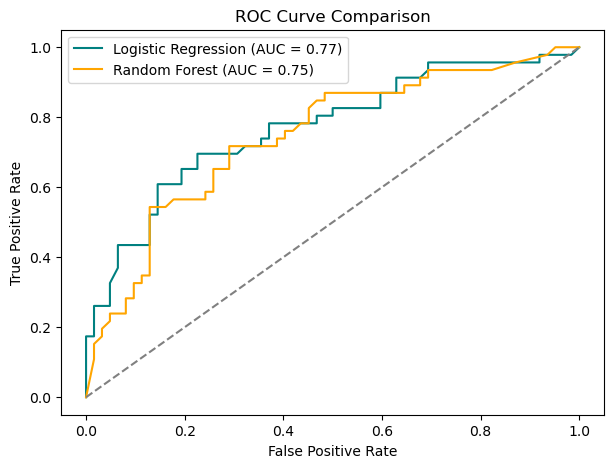

In [186]:
from sklearn.metrics import roc_curve, auc

# Get probabilities instead of labels
y_pred_lr_prob = log_reg.predict_proba(X_test_scaled)[:,1]
y_pred_rf_prob = rf.predict_proba(X_test)[:,1]

# Compute ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_prob)

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})', color='teal')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', color='orange')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


# ROC Curve Comparison between logistic regression and Random Forest

The figure above compares the ROC curves for Logistic Regression and Random Forest classifiers trained to predict top-ten Grand Prix Finishes using sprint race features.

Both models show strong discriminatory ability, with AUC scores of 0.77 (Logistic Regression) and 0.75 (Random Forest), well above the random baseline of 0.5. This indicates that sprint performance metrics provide meaningful predictive information for main-race outcomes.

The higher AUC for logistic regression suggets that the relationship between sprint and final race performance is linear, and additional non-linear modelling through Random Forest does not significantly enhance prediction accuracy. 


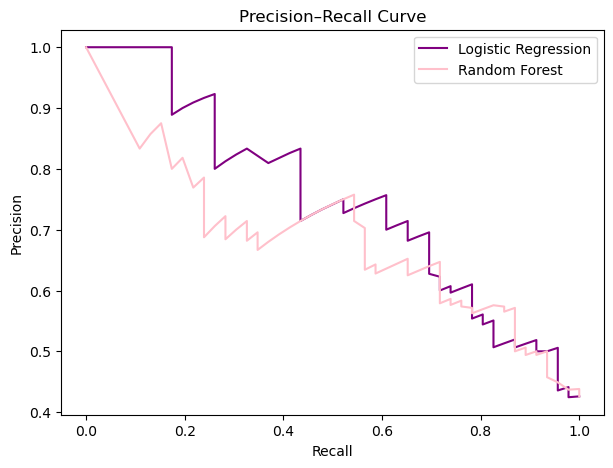

In [189]:
from sklearn.metrics import precision_recall_curve

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_pred_lr_prob)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_pred_rf_prob)

plt.figure(figsize=(7,5))
plt.plot(rec_lr, prec_lr, label='Logistic Regression', color='purple')
plt.plot(rec_rf, prec_rf, label='Random Forest', color='pink')
plt.title('Precision–Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

The figure compares the precision-recall trade off for the logistic regression and random forest classifiers predicting top-ten Grand Prix finishes using sprint metrics. 

Both model maintain high precision across most recall levels, indicating strong positive class discrimination even under varying decision thresolds. 

Logistic regression exhibits slightly superior balance, with consitently higher precision for the same recall values, suggesting that the relationship between sprint and race results is largely linear and stable.

The Random Forest model captures a similar trend but with marginally lower precision, reflecting a greater tendency to overpredict top-ten outcomes. 


# Applying Unsupervised Learning (kMeans)

In [190]:
features = merged[['positionOrder_sprint','positionOrder_race','position_change','points_sprint']]

In [191]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [192]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
merged['cluster'] = kmeans.fit_predict(X_scaled)

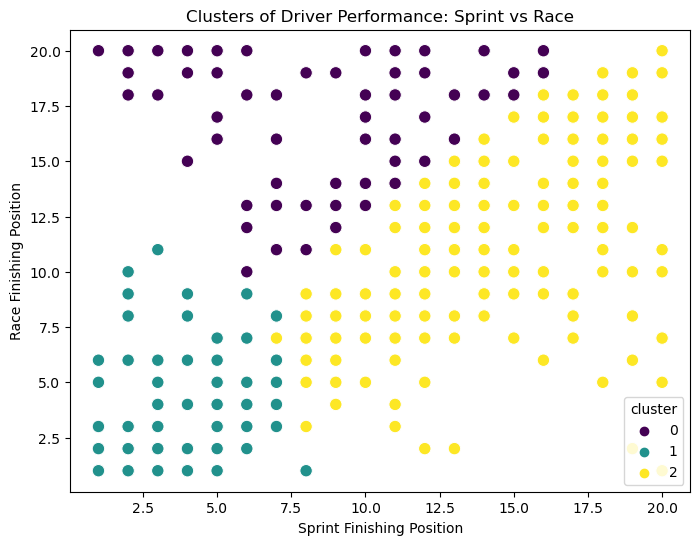

In [194]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='positionOrder_sprint',
    y='positionOrder_race',
    hue='cluster',
    data=merged,
    palette = 'viridis',
    s=80
)

plt.title('Clusters of Driver Performance: Sprint vs Race')
plt.xlabel('Sprint Finishing Position')
plt.ylabel('Race Finishing Position')
plt.show()

The figure illustrates three clusters of driver performance patterns derived using the K-Means clustering algorithm.

Cluster 1 in green represents consistent performers who maintain strong finishing positions across both sprint and main race sessions.

Cluster 0 in purple captures the drivers whose position has declined, drivers who perform well in the sprint but lose positions in the Grand Prix.

Cluster 2 denotes strugglers who basically finish low in both sessions. 

This unsupervised learning analysis highlights that while sprint results moderately predict race performance, drivers exhibit heterogeneous behaviors in translating sprint success into main race outcomes. 

Such clustering provides a nuanced understanding of performance patterns that complements the supervised predictive findings.


In [195]:
kmeans = KMeans(n_clusters=3, random_state=42)
merged['cluster'] = kmeans.fit_predict(X_scaled)


In [196]:
# Compute mean sprint and race stats per cluster
cluster_summary = merged.groupby('cluster')[['positionOrder_sprint', 'positionOrder_race', 'position_change', 'points_sprint']].mean().round(2)
print(cluster_summary)


         positionOrder_sprint  positionOrder_race  position_change  \
cluster                                                              
0                        8.86               16.72            -7.87   
1                        3.60                3.82            -0.22   
2                       14.46               11.24             3.22   

         points_sprint  
cluster                 
0                 1.41  
1                 4.77  
2                 0.06  


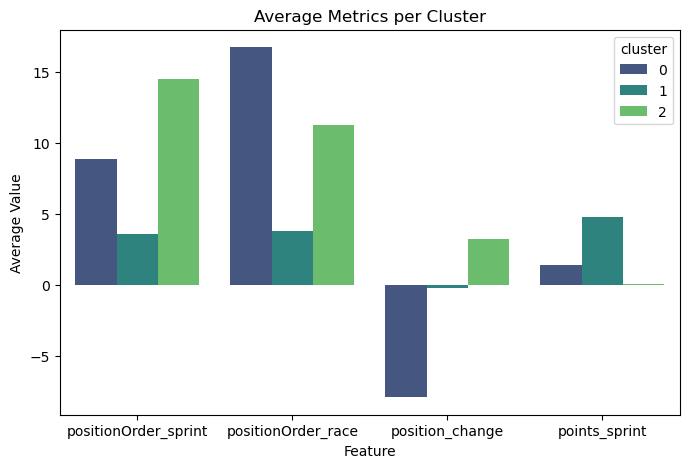

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=cluster_summary.reset_index().melt(id_vars='cluster'),
            x='variable', y='value', hue='cluster', palette='viridis')
plt.title('Average Metrics per Cluster')
plt.xlabel('Feature')
plt.ylabel('Average Value')
plt.show()


# Average Sprint and Race Metrics by Driver Cluster

The figure presents the mean sprint and race performance metrics for each driver cluster identified through the K-Means algorithm.

Cluster 1 (teal) represents consistent performers, maintaining strong finishing positions and scoring the highest average sprint points.

Cluster 0 (dark blue) captures decliners, who perform well in the sprint but lose significant ground during the Grand Prix, indicated by a large negative position change.

Cluster 2 (light green) includes strugglers, consistently finishing in the lower order of both sessions.

This quantitative summary reinforces the earlier visual clustering results, confirming that while sprint results moderately predict main-race outcomes, driver behavior patterns diverge substantially, reflecting differences in race pace, strategy execution, and team competitiveness.

# Q3: How has the relationship between qualifying position and finishing position evolved across decades?

In [213]:
#loading the data

races = pd.read_csv('dataset/races.csv')
results = pd.read_csv('dataset/results.csv')

In [214]:
#Step 2 - Cleaning the data

#adding years to the results
res = results.merge(races[['raceId','year']], on='raceId', how='left')

#keep only rows with valid starting grid and finishing order
res.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008


In [215]:
#ensuring that the starting grid is greater than 0 and positionOrder doesn't have NA's
res = res[(res['grid']>0) & (res['positionOrder']>0) & (res['positionOrder'].notna())]

In [216]:
#Focussing on Era

res = res[(res['year']>=1950) & res['year']<=2024].copy()

#categorising based on decades
res['decade'] = (res['year']//10)*10

res.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,decade
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008,2000
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008,2000
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008,2000
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008,2000
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008,2000


In [221]:
#step 3 - Exploratory data checks

print(res[['grid','positionOrder','year','decade']].describe())

               grid  positionOrder          year        decade
count  25121.000000   25121.000000  25121.000000  25121.000000
mean      11.860834      11.858644   1991.968552   1987.641017
std        6.830260       6.825425     20.161266     20.353765
min        1.000000       1.000000   1950.000000   1950.000000
25%        6.000000       6.000000   1977.000000   1970.000000
50%       12.000000      12.000000   1993.000000   1990.000000
75%       17.000000      17.000000   2010.000000   2010.000000
max       34.000000      34.000000   2024.000000   2020.000000


In [222]:
#distribution of sample size across decade
print(res['decade'].value_counts().sort_index())

decade
1950    1939
1960    1915
1970    3456
1980    3932
1990    3893
2000    3635
2010    4269
2020    2082
Name: count, dtype: int64


In [223]:
#step 4 - finding correlation between grid and finishing per decade

corr_rows=[]

for dec, group in res.groupby('decade'):
    if len(group) >= 50:
        pear = group['grid'].corr(group['positionOrder'],method='pearson')
        spear = group['grid'].corr(group['positionOrder'],method='spearman')
        corr_rows.append({
            'decade': dec,
            'pearson_corr':pear,
            'spearman_corr':spear,
            'n':len(group)
        })
corr_by_decade = pd.DataFrame(corr_rows).sort_values('decade')
print(corr_by_decade)

   decade  pearson_corr  spearman_corr     n
0    1950      0.436558       0.440069  1939
1    1960      0.391863       0.367214  1915
2    1970      0.331802       0.334500  3456
3    1980      0.314870       0.316501  3932
4    1990      0.397340       0.401560  3893
5    2000      0.504912       0.507433  3635
6    2010      0.619455       0.627624  4269
7    2020      0.621767       0.625090  2082


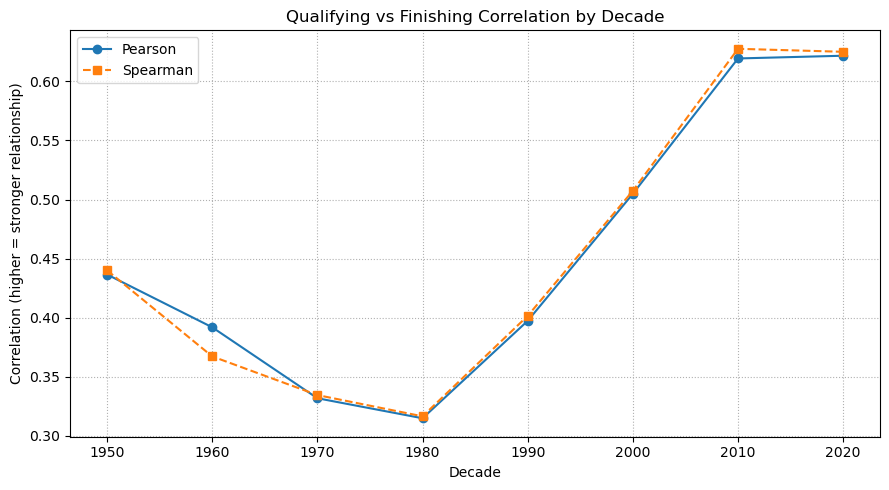

In [225]:
plt.figure(figsize=(9,5))
plt.plot(corr_by_decade['decade'], corr_by_decade['pearson_corr'],
         marker='o', label='Pearson')
plt.plot(corr_by_decade['decade'], corr_by_decade['spearman_corr'],
         marker='s', label='Spearman', linestyle='--')
plt.title('Qualifying vs Finishing Correlation by Decade')
plt.xlabel('Decade')
plt.ylabel('Correlation (higher = stronger relationship)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

The above figure presents Pearson and Spearman correlations between qualifying and finishing positions across decades.

The relationship was week during the high attrition 1970-1980 but strengthened sharply from the 1990's decade, where the values reached above 0.6 in the 2010-2020s.

This trend demonstrates that qualifying performance has become increasingly decisive in determining final race outcomes as car reliability, aerodynamics, and strategic uniformity have evolved.

In [227]:
#Applying linear regression

from sklearn.linear_model import LinearRegression

regression_rows = []

for dec, group in res.groupby('decade'):
    if len(group) >= 50:
        X = group[['grid']].values
        y = group['positionOrder'].values
        
        model = LinearRegression()
        model.fit(X,y)
        
        r2 = model.score(X,y)
        slope = model.coef_[0]
        intercept = model.intercept_
        
        regression_rows.append({
            'decade': dec,
            'r2': r2,
            'slope': slope,
            'intercept': intercept,
            'n':len(group)
        })
        
reg_by_decade = pd.DataFrame(regression_rows).sort_values('decade')
print(reg_by_decade)

   decade        r2     slope  intercept     n
0    1950  0.190583  0.434560   6.790477  1939
1    1960  0.153556  0.386972   6.350025  1915
2    1970  0.110093  0.331277   8.447847  3456
3    1980  0.099143  0.314376   9.020734  3932
4    1990  0.157879  0.397286   7.598704  3893
5    2000  0.254936  0.504866   5.432029  3635
6    2010  0.383724  0.620668   4.324397  4269
7    2020  0.386594  0.633158   3.873029  2082


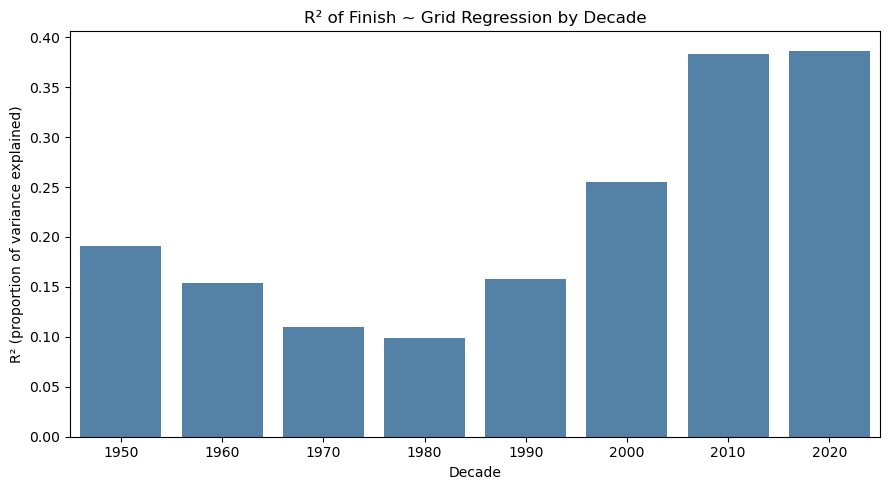

In [228]:
plt.figure(figsize=(9,5))
sns.barplot(x='decade', y='r2', data=reg_by_decade, color='steelblue')
plt.title('R² of Finish ~ Grid Regression by Decade')
plt.xlabel('Decade')
plt.ylabel('R² (proportion of variance explained)')
plt.tight_layout()
plt.show()

The figure presents the decade wise R2 values from linear regressions of finishing position on qualifying position.

The explanatory power of qualifying improved markedly from the 1970s which was 0.11 to 0.39 in 2020s.

This indicates that approximately 40% of the race result variance is now explained by grid position only as compared to the 10% in earlier decades.

This trend also reflects greater car reliability, aerodynamic senstivity, and strategic uniformity in modern era which leads to more predictable race outcomes.